len(de) = 585648
len(dl) = 585648
len(vlm) = 585648


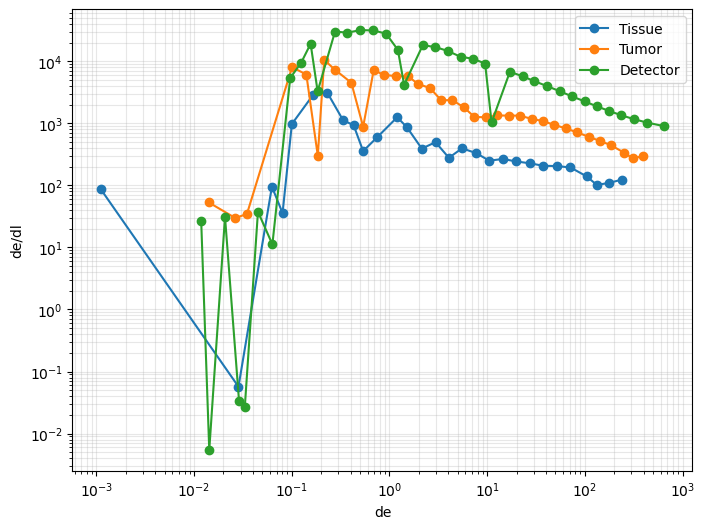

In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

file_path = "tumor.root"

# Volume labels
vlm_labels = {
    2: "Tissue",
    3: "Tumor",
    6: "Detector"
}

with uproot.open(file_path) as f:
    tree = f["t"]

    de = np.concatenate(tree["de"].array(library="np")).ravel()
    dl = np.concatenate(tree["dl"].array(library="np")).ravel()
    vlm = np.concatenate(tree["vlm"].array(library="np")).ravel()

# safety check
print("len(de) =", len(de))
print("len(dl) =", len(dl))
print("len(vlm) =", len(vlm))

plt.figure(figsize=(8, 6))

for v in [2, 3, 6]:
    mask = (vlm == v) & (dl > 0) & (de > 0)

    de_v = de[mask]
    dl_v = dl[mask]
    dedl_v = de_v / dl_v

    # remove zeros for log scale safety
    valid = de_v > 0
    de_v = de_v[valid]
    dedl_v = dedl_v[valid]

    bins = np.logspace(np.log10(de_v.min()), np.log10(de_v.max()), 40)
    inds = np.digitize(de_v, bins)

    xvals, yvals = [], []

    for i in range(1, len(bins)):
        bin_mask = (inds == i)
        if np.any(bin_mask):
            xvals.append(np.median(de_v[bin_mask]))
            yvals.append(np.mean(dedl_v[bin_mask]))

    plt.plot(xvals, yvals, marker="o", label=vlm_labels[v])

plt.xscale("log")
plt.yscale("log")
plt.xlabel("de")
plt.ylabel("de/dl")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()